<center><h1>Groome_Henry_HW2</h1></center>
<br>
<br>

Name: Henry Groome
<br>
Github Username: hgroome46
<br>
USC ID: 4479346040

I used Claude to assist me with code in sections 1.3-1.10. 

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
%pip install numpy pandas matplotlib seaborn openpyxl statsmodels scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split




Note: you may need to restart the kernel to use updated packages.


Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('CCPP/Folds5x2_pp.xlsx', sheet_name=0)
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
rows, cols = df.shape
print(f"rows: {rows}, columns: {cols}")


rows: 9568, columns: 5


columns represent 4 predictors and one output (EP) which is what we are trying to predict. Rows represent a measurement taken every hour. 

#### ii. pairwise scatterplots of all the varianbles

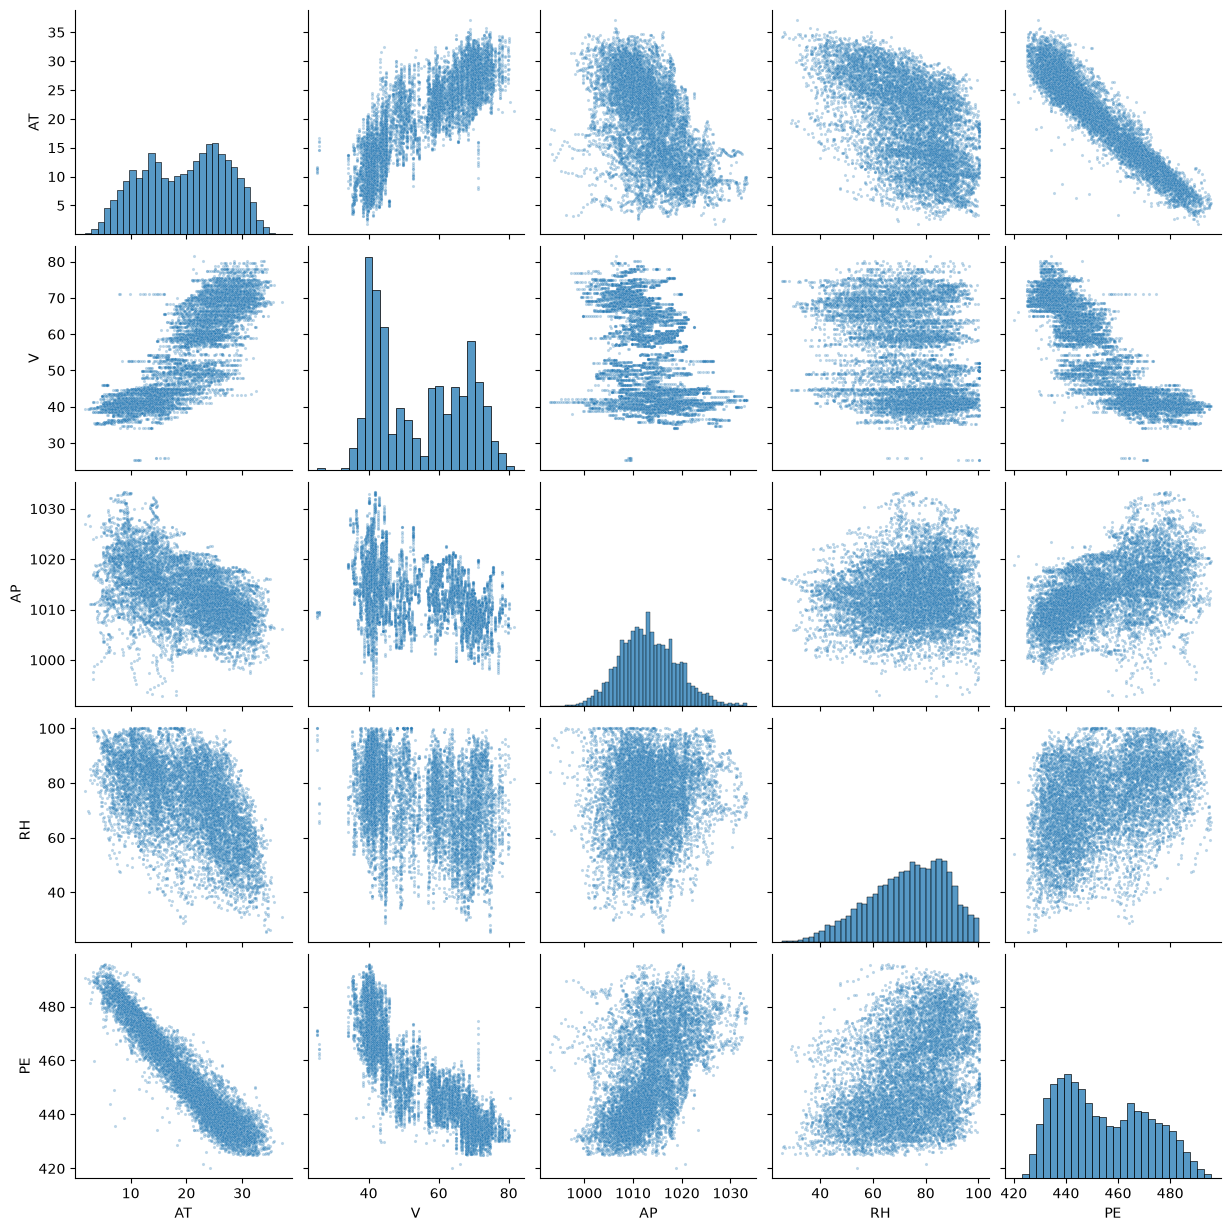

In [4]:
sns.pairplot(df, plot_kws={'s':5, 'alpha':.3})
plt.show()


Findings:
Temperature (AT) and Electrical Energy Output (PE) seem to be negatively correlated, where a higher temperature means a lower energy output. Same goes for exhaust vacuum and energy output, with a less strong but still noticible correlation where higher exhaust levels mean lower energy output. There is also a correlation between exhaust vacuum and temperature in the graphs, which is interesting since both features impact the dependant variable of energy output. Some variables like relative humidity and ambient pressure don't seem to have any high correlation with other features, since their scatterplots are pretty central and dispersed. 

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [6]:
desc = df.describe()
stats = pd.DataFrame({
    'Mean' : desc.loc['mean'],
    'Median' : desc.loc['50%'],
    'Range' : desc.loc['max'] - desc.loc['min'],
    '1Q' : desc.loc['25%'],
    '3Q' : desc.loc['75%'],
    'IQR' : desc.loc['75%'] - desc.loc['25%']
})

stats.round(2)

,Mean,Median,Range,1Q,3Q,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


### (c) Simple Linear Regression

In [7]:
predictors = ['AT', 'V', 'AP', 'RH']
simple_models = {}

for p in predictors:
    simple_models[p] = smf.ols(f'PE ~ {p}', data=df).fit()
    print(simple_models[p].summary().tables[1])
    print(f"R-squared: {simple_models[p].rsquared:.3f}\n")

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.000     496.727     497.341
AT            -2.1713      0.007   -291.715      0.000      -2.186      -2.157
R-squared: 0.899

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.000     517.061     518.542
V             -1.1681      0.007   -172.402      0.000      -1.181      -1.155
R-squared: 0.757

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.000   -1105.167   -1005.355
AP             1.4899      0.025     59.296      0.000       1.441       1.539
R-squared: 0.269

According to linear regression on all the independant variables, there is statistical significance between them and energy output, as all p-values are well below .001. Note though that R-squared value of AP and RH is below .3, or 30%, showing that there is a lot of variance between the data and the predicted regression line, and therefore not a strong correlation even with a low p-value. 

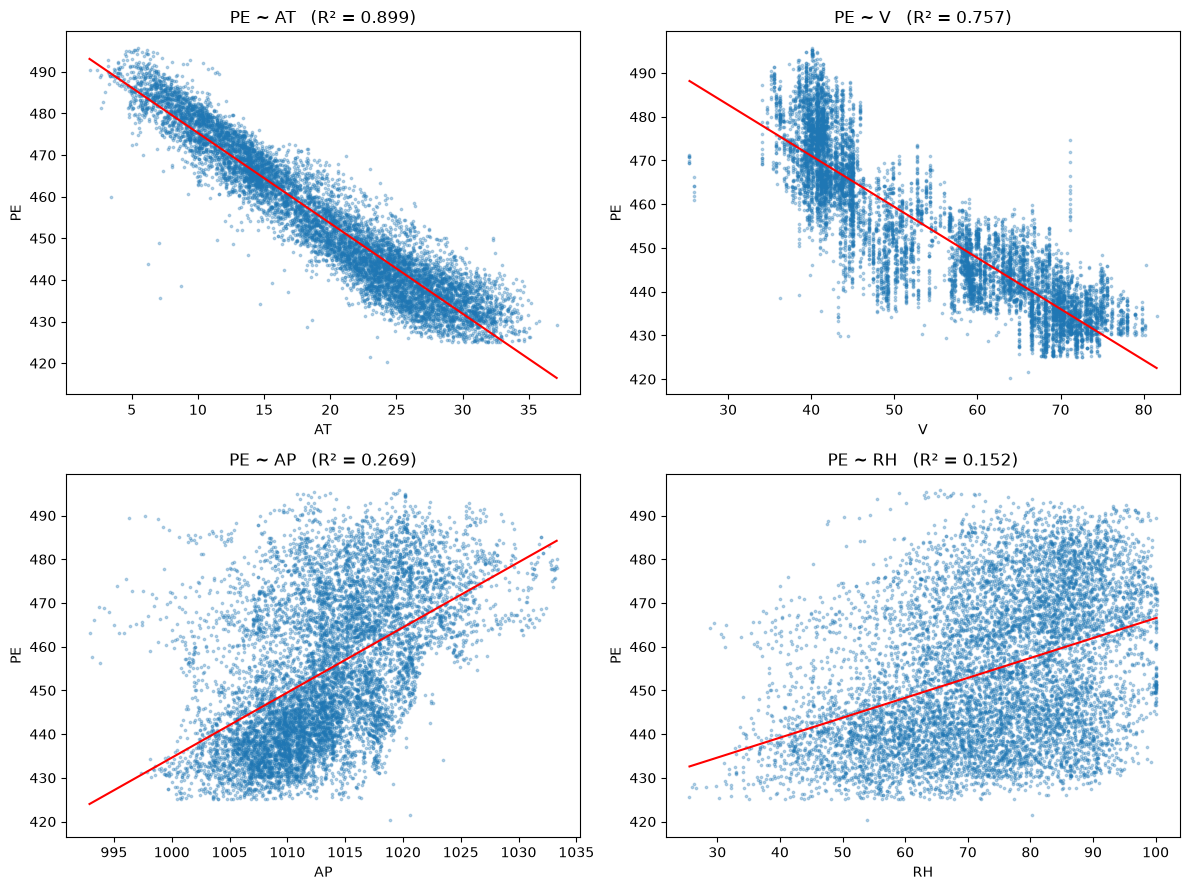

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, p in zip(axes.flat, predictors):
    m = simple_models[p]
    ax.scatter(df[p], df['PE'], s=3, alpha=0.3)
    x_line = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(x_line, m.params['Intercept'] + m.params[p] * x_line, color='red')
    ax.set_xlabel(p)
    ax.set_ylabel('PE')
    ax.set_title(f'PE ~ {p}   (R² = {m.rsquared:.3f})')

plt.tight_layout()
plt.show()

In [9]:
for p in predictors:
    m = simple_models[p]
    std_resid = m.get_influence().resid_studentized_internal
    n_out = (np.abs(std_resid) > 3).sum()
    print(f"{p}: {n_out} outliers ({n_out/len(df):.2%} of data)")

AT: 42 outliers (0.44% of data)
V: 33 outliers (0.34% of data)
AP: 29 outliers (0.30% of data)
RH: 2 outliers (0.02% of data)


In [10]:
for p in predictors:
    m = simple_models[p]
    keep = np.abs(std_resid) <= 3
    m_clean = smf.ols(f'PE ~ {p}', data=df[keep]).fit()
    print(f"{p}: slope {m.params[p]:.4f} → {m_clean.params[p]:.4f}, "
          f"R² {m.rsquared:.3f} → {m_clean.rsquared:.3f}")

AT: slope -2.1713 → -2.1708, R² 0.899 → 0.899
V: slope -1.1681 → -1.1677, R² 0.757 → 0.757
AP: slope 1.4899 → 1.4897, R² 0.269 → 0.269
RH: slope 0.4557 → 0.4564, R² 0.152 → 0.153


There aren't many outliers to begin with in this data, considering there are over 9,000 rows. Also, removing them barely influences the b1 slope value across all features. Because of this, I would not remove any outliers for future testing on this dataset.

### (d) Multiple Regression

In [11]:
multi_model = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:08:57   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

According to the results, the p-values for all the features is still <.001, meaning we can reject the null hypothesis for all variables. There were a few significant changes in coefficients for our features, though. V and AP both saw flattening, getting closer to 0 where AT only changed a little. Perhaps the most significant change was RH having a negative slope in multiple regression when it had a positive one in simple linear regression, meaning that when isolated from the effects of the other features, actually had a negative effect on energy output. 

### (e) 1c Compare to 1d

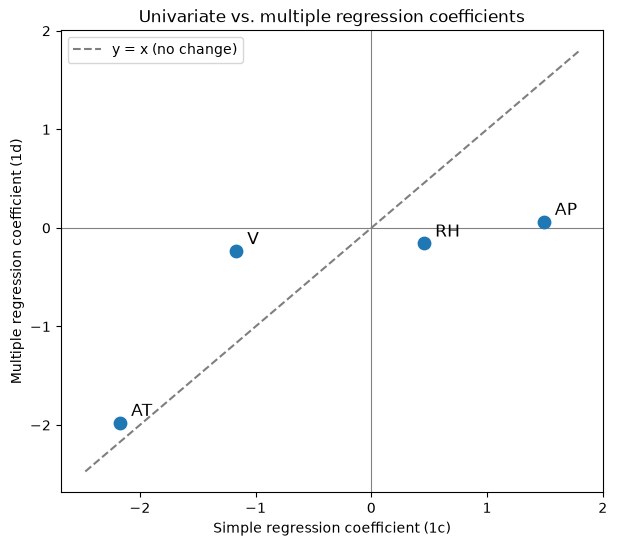

In [12]:
simple_coefs = [simple_models[p].params[p] for p in predictors]
multi_coefs  = [multi_model.params[p] for p in predictors]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(simple_coefs, multi_coefs, s=80, color='tab:blue', zorder=3)

for p, x, y in zip(predictors, simple_coefs, multi_coefs):
    ax.annotate(p, (x, y), xytext=(8, 5), textcoords='offset points', fontsize=12)

lims = [min(simple_coefs + multi_coefs) - 0.3, max(simple_coefs + multi_coefs) + 0.3]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x (no change)')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)

ax.set_xlabel('Simple regression coefficient (1c)')
ax.set_ylabel('Multiple regression coefficient (1d)')
ax.set_title('Univariate vs. multiple regression coefficients')
ax.legend()
plt.show()

Based on this plot we can see that RH and AP had decreased multiple regression coefficients, being below the dashed line, and that AT and V had increased coefficients. AP and V saw the most significant changes.

### (f) Nonlinear Association

In [13]:
df_c = df.copy()
for p in predictors:
    df_c[p] = df[p] - df[p].mean()  #predictors mean-centered to avoid numerical instability


cubic_models = {}
for p in predictors:
    cubic_models[p] = smf.ols(f'PE ~ {p} + I({p}**2) + I({p}**3)', data=df_c).fit()
    print(f"===== {p} =====")
    print(cubic_models[p].summary().tables[1])
    print(f"R² linear: {simple_models[p].rsquared:.4f}  →  cubic: {cubic_models[p].rsquared:.4f}\n")

===== AT =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.7081      0.074   6085.240      0.000     452.562     452.854
AT            -2.4297      0.015   -167.160      0.000      -2.458      -2.401
I(AT ** 2)     0.0326      0.001     33.381      0.000       0.031       0.034
I(AT ** 3)     0.0027      0.000     22.594      0.000       0.002       0.003
R² linear: 0.8989  →  cubic: 0.9119

===== V =====
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    451.2137      0.144   3124.596      0.000     450.931     451.497
V             -1.2503      0.015    -85.722      0.000      -1.279      -1.222
I(V ** 2)      0.0192      0.001     24.714      0.000       0.018       0.021
I(V ** 3)      0.0001   5.45e-05      2.465      0.014    2.75e-0

Looking at these results, there is statistical significance in at least one of the nonlinear coefficients in each feature, though this doesn't necessarily determine the strength of the non-linear relationship. According to the p-values, AT and AP has significance on both coefficients, but RH is not significant where X^2, and V is barely signficant where X^3. The R-squared values for all features didn't change much, so no feature stood out as having an especially strong non-linear association with the output. 

### (g) Interactions of Predictors

In [14]:
interact_model = smf.ols('PE ~ (AT + V + AP + RH)**2', data=df_c).fit()
print(interact_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:08:57   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.6946      0.075   6074.393      0.0

It looks like the interaction between AT and V, AT and RH, and V and AP are statistically significant, and AP and RH is borderline significant, nearing a p-value of .5, whereas all other interactions have p-values above .05. 

### (h) Improvement

In [15]:
train, test = train_test_split(df_c, test_size=0.3, random_state=42)

def mse(model, data):
    return np.mean((data['PE'] - model.predict(data))**2)

model_A = smf.ols('PE ~ AT + V + AP + RH', data=train).fit()


In [16]:
train = train.copy()
test = test.copy()
for p in predictors:
    train[p + '2'] = train[p]**2
    test[p + '2'] = test[p]**2

from itertools import combinations

main  = predictors[:]                                  # ['AT','V','AP','RH']
inter = [f'{a}:{b}' for a, b in combinations(predictors, 2)]
quad  = [p + '2' for p in predictors]
terms = main + inter + quad

def parents(term):
    if ':' in term:
        return term.split(':')        # 'AT:V' depends on AT and V
    if term.endswith('2'):
        return [term[:-1]]            # 'AT2' depends on AT
    return []                         # main effects depend on nothing

while True:
    model_B = smf.ols('PE ~ ' + ' + '.join(terms), data=train).fit()
    protected = {par for t in terms for par in parents(t)}
    candidates = {t: model_B.pvalues[t] for t in terms if t not in protected}
    worst = max(candidates, key=candidates.get)
    if candidates[worst] > 0.05:
        print(f"Removing {worst} (p = {candidates[worst]:.3f})")
        terms.remove(worst)
    else:
        break

print("\nFinal terms:", terms)
print(model_B.summary().tables[1])

Removing V:RH (p = 0.867)
Removing V2 (p = 0.608)
Removing V:AP (p = 0.358)

Final terms: ['AT', 'V', 'AP', 'RH', 'AT:V', 'AT:AP', 'AT:RH', 'AP:RH', 'AT2', 'AP2', 'RH2']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    453.1645      0.099   4581.937      0.000     452.971     453.358
AT            -1.8152      0.020    -92.950      0.000      -1.853      -1.777
V             -0.2983      0.009    -33.607      0.000      -0.316      -0.281
AP             0.1169      0.012     10.078      0.000       0.094       0.140
RH            -0.1252      0.005    -24.479      0.000      -0.135      -0.115
AT:V           0.0082      0.001      5.663      0.000       0.005       0.011
AT:AP          0.0070      0.002      3.174      0.002       0.003       0.011
AT:RH         -0.0055      0.001     -5.742      0.000      -0.007      -0.004
AP:RH         -0.0034      0.001     -3.

In [17]:
print(f"Model A  train MSE: {mse(model_A, train):.3f}   test MSE: {mse(model_A, test):.3f}")
print(f"Model B  train MSE: {mse(model_B, train):.3f}   test MSE: {mse(model_B, test):.3f}")

Model A  train MSE: 20.581   test MSE: 21.240
Model B  train MSE: 17.891   test MSE: 18.660


### (i) KNN

In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

k_values = list(range(1, 101, 1))

raw_features = predictors          

X_train_raw = train[raw_features]
X_test_raw  = test[raw_features]
y_train = train['PE']
y_test  = test['PE']

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm  = scaler.transform(X_test_raw)

train_err_raw = []
test_err_raw = []

train_err_norm = []
test_err_norm = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors= k)
    knn.fit(X_train_raw, y_train)
    train_err_raw.append(mean_squared_error(y_train, knn.predict(X_train_raw)))
    test_err_raw.append(mean_squared_error(y_test,  knn.predict(X_test_raw)))

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_norm, y_train)
    train_err_norm.append(mean_squared_error(y_train, knn.predict(X_train_norm)))
    test_err_norm.append(mean_squared_error(y_test,  knn.predict(X_test_norm)))

In [19]:
best_k_raw  = k_values[np.argmin(test_err_raw)]
best_k_norm = k_values[np.argmin(test_err_norm)]

print(f"Raw: best k = {best_k_raw},  test MSE = {min(test_err_raw):.3f}")
print(f"Normalized: best k = {best_k_norm}, test MSE = {min(test_err_norm):.3f}")

Raw: best k = 5,  test MSE = 15.727
Normalized: best k = 4, test MSE = 14.306


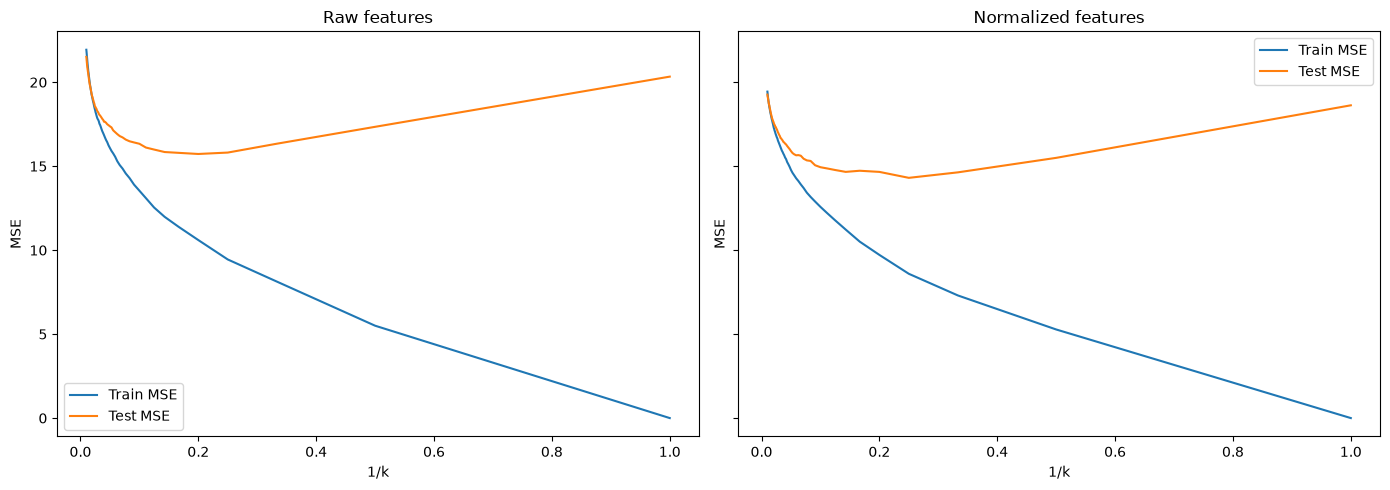

In [20]:
inv_k = [1/k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, tr, te, title in [(axes[0], train_err_raw, test_err_raw, 'Raw features'),
                          (axes[1], train_err_norm, test_err_norm, 'Normalized features')]:
    ax.plot(inv_k, tr, label='Train MSE')
    ax.plot(inv_k, te, label='Test MSE')
    ax.set_xlabel('1/k')
    ax.set_ylabel('MSE')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

### (j ) Compare KNN and Linear

The KNN model with the smallest MSE was normalized values, with a test MSE of 14. 306. The regression model with the smallest MSE was model B, which included significant non-linear features and interaction features while removing non-significant features, resulting in a test MSE of 18.660. The reason for this difference is because KNN is comparing nearest neighbors, so it can pick up on patterns I never specified. The regression models require specification of features, which with the right selection can get a pretty low test error, but won't always pick up on every factor influencing the data. The tradeoff is that with KNN we don't know which features contribute most to the curve. 

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible model is more suitable. This is because with a large sample size, there is enough data to keep variance low, preventing overfitting. That is why a model like KNN works well with a large dataset because it can leverage the high volume of neighbors to create an accurate prediction. An inflexible model with small amount of predictors is subject to bias and won't leverage the dense sample size. 

### (b) The number of predictors p is extremely large, and the number of observations n is small.

With a small sample size of observations and a lot of prediction points, a flexible model might overfit the curve. An inflexible model will ignore the noise and create a curve with less variance. The dimensionality of this situation requires a more rigid model. 

### (c) The relationship between the predictors and response is highly non-linear.

A flexible model is more optimal for a dataset with a non-linear relationship between predictors and response because inflexible models will produce rigid, linear shapes that won't account for the non-linearity of the relationship. A flexible method like KNN or polynomial regression can adapt to the true shape of the relationship, as we saw earlier where MSE dropped as we increased flexibility. 

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

When variance in error terms is extremely high, the data is inherently very noisy. An inflexible model like linear regression is less sensitive to this noise, fitting the data to a straight line, wheras a flexible model will overfit the data to account for the noise, which in this case is negatively impacting the accuracy of the prediction because it's variance is extremely high. 

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [21]:
X = np.array([[0,3,0],[2,0,0],[0,1,3],[0,1,2],[-1,0,1],[1,1,1]])
test_point = np.array([0,0,0])
np.sqrt(((X - test_point)**2).sum(axis=1))

array([3.        , 2.        , 3.16227766, 2.23606798, 1.41421356,
       1.73205081])

### (b) What is our prediction with K = 1? Why?

The closest neighbor is observation 5, with a euclidean distance of 1.41421356. Because observation 5's response is green, our prediction with K=1 is green. 

### (c) What is our prediction with K = 3? Why?

The three nearest neighbors are observation 5, 6, and 2. Observation 2 and 6 are both red, so as the majority, our prediction for K=3 is red. 

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

For a highly non-linear decision boundary, the best value for K is small. A larger K groups in observations on the other side of the curve, increasing bias, wheras a smaller K creates a more flexible model that accounts for the non-linearity of the boundary. 